<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/Longevity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [12]:
# Load Data
fpath = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/Updated Quality of Life Data.csv'
df = pd.read_csv(fpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [13]:
df.describe()

,id,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,15000.50000,9.211857,5.964582,7.364192,1.459726,79.85060
std,2886.89568,2.903739,3.152097,2.214386,0.954428,12.02562
min,10001.00000,0.010000,0.000000,0.000000,0.000000,25.00000
25%,12500.75000,7.740000,3.890000,6.310000,0.650000,74.00000
50%,15000.50000,8.960000,5.830000,7.390000,1.440000,81.00000
75%,17500.25000,10.440000,7.670000,8.470000,2.250000,88.00000
max,20000.00000,23.970000,23.930000,19.980000,5.930000,100.00000


In [15]:
gender_counts = df['gender'].value_counts()
display(gender_counts)

,count
gender,
Female,5102
Male,4898


In [17]:
occupation_counts = df['occupation_type'].value_counts()
display(occupation_counts)

,count
occupation_type,
Freelancer,778
Teacher,764
Office Worker,755
Scientist,738
Driver,725
Technician,724
Manager,717
Retail Worker,712
Consultant,710


Exploratory Data

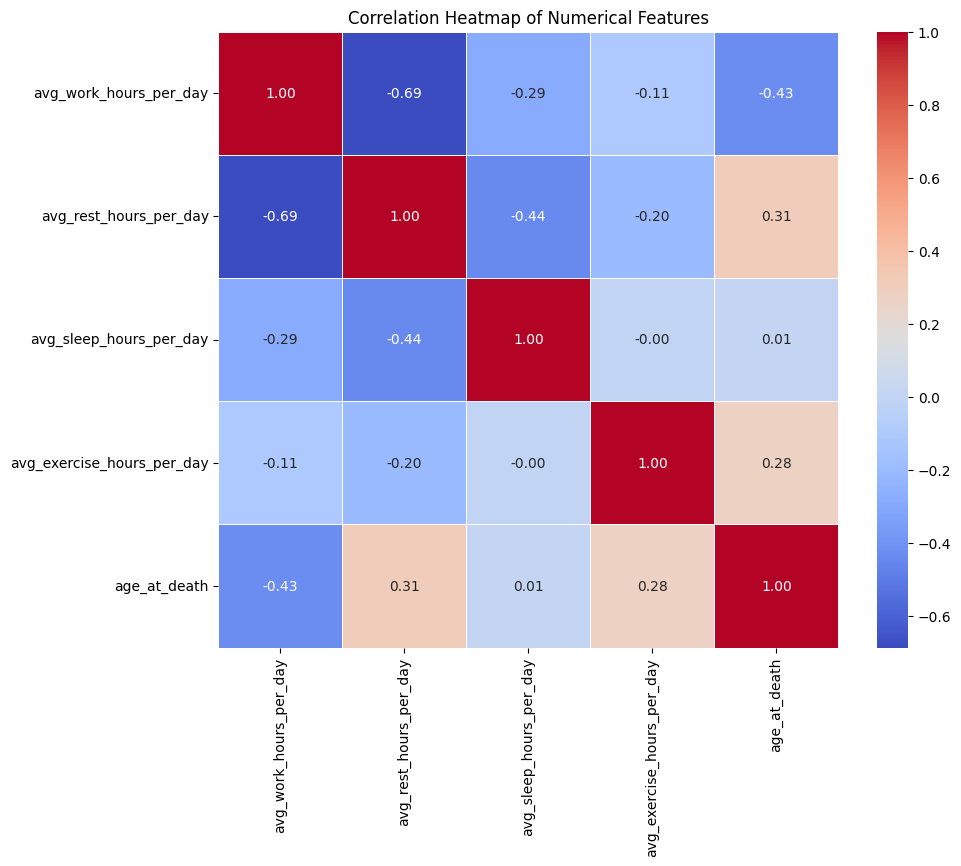

In [19]:

# Select only numerical columns for correlation calculation, excluding 'id'
# (assuming 'id' is just an identifier and not a meaningful numerical feature for correlation)
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

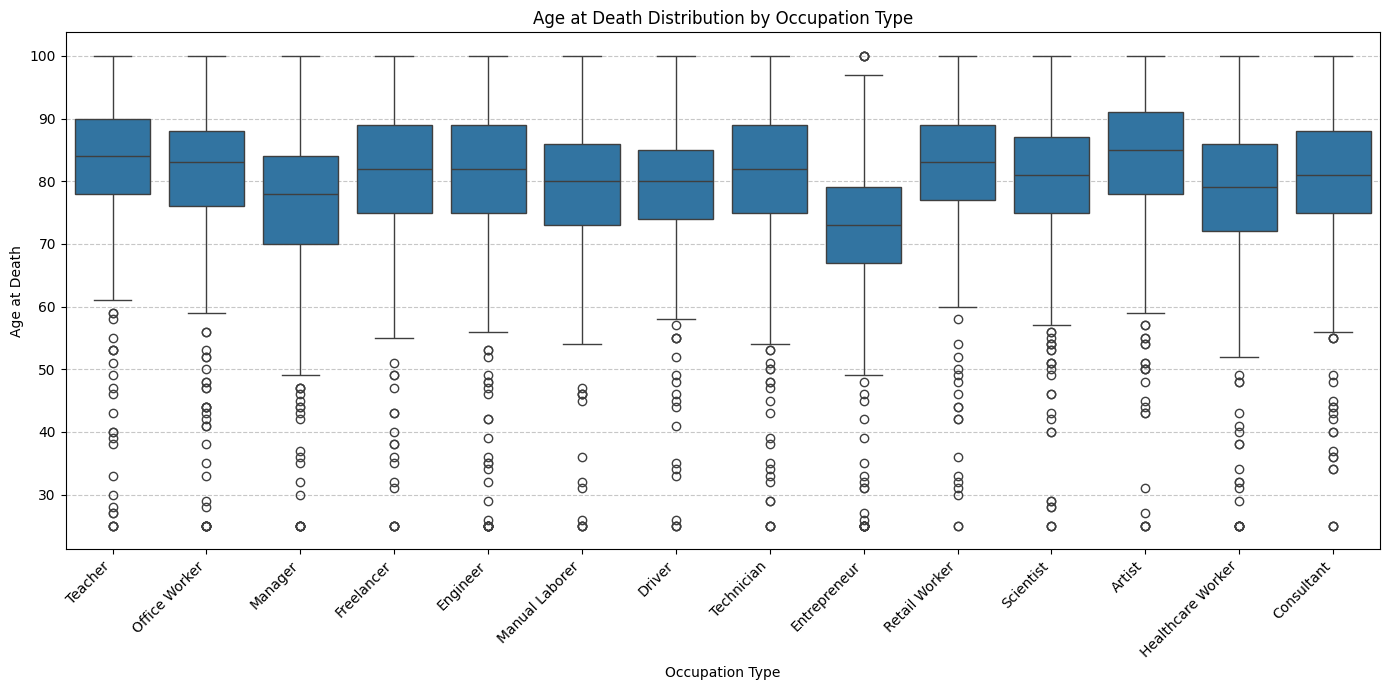

In [20]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='occupation_type', y='age_at_death', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Age at Death Distribution by Occupation Type')
plt.xlabel('Occupation Type')
plt.ylabel('Age at Death')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

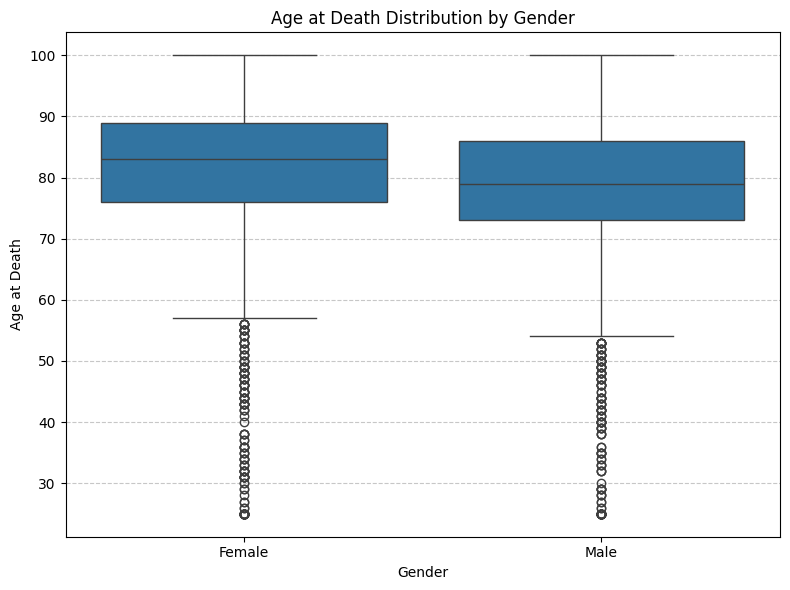

In [21]:


plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='age_at_death', data=df)
plt.title('Age at Death Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age at Death')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

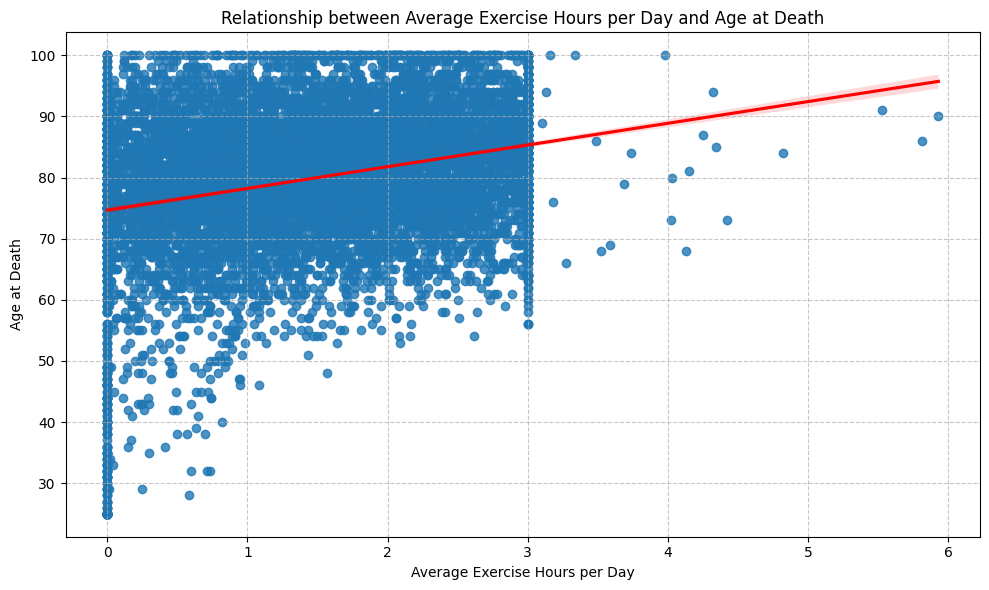

In [33]:


plt.figure(figsize=(10, 6))
sns.regplot(x='avg_exercise_hours_per_day', y='age_at_death', data=df, line_kws={'color': 'red'})
plt.title('Relationship between Average Exercise Hours per Day and Age at Death')
plt.xlabel('Average Exercise Hours per Day')
plt.ylabel('Age at Death')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

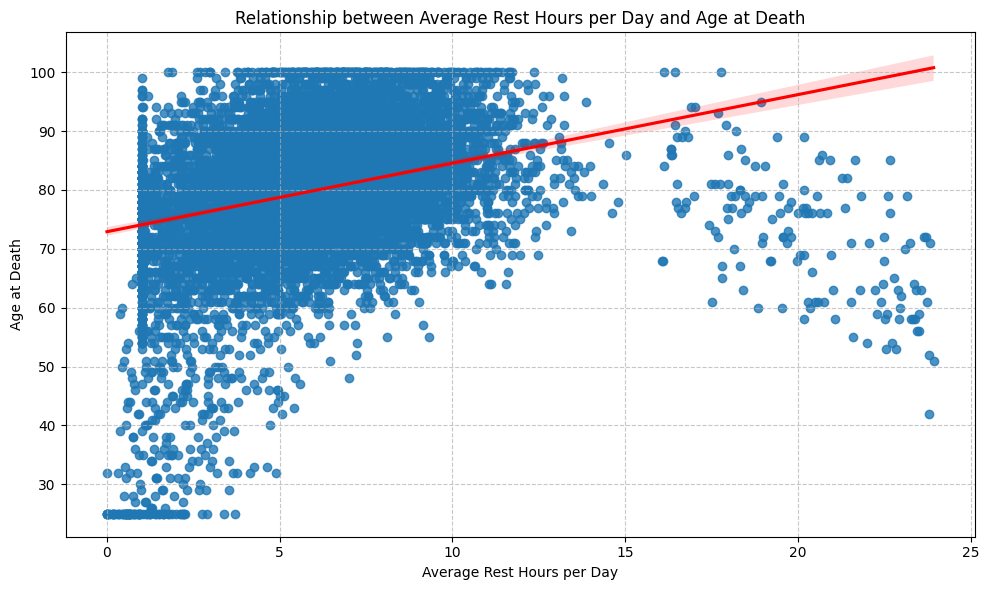

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='avg_rest_hours_per_day', y='age_at_death', data=df, line_kws={'color': 'red'})
plt.title('Relationship between Average Rest Hours per Day and Age at Death')
plt.xlabel('Average Rest Hours per Day')
plt.ylabel('Age at Death')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

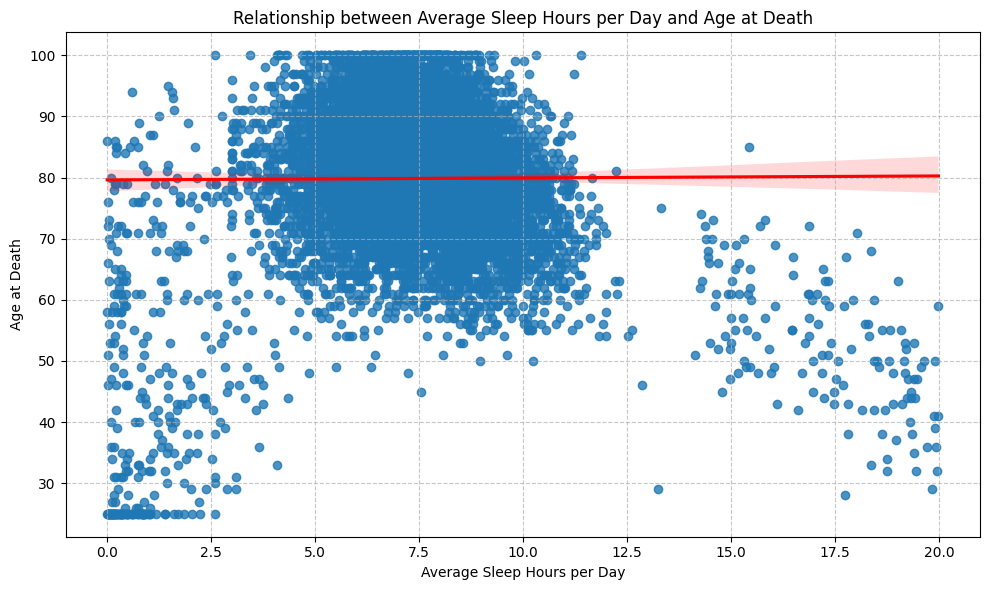

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='avg_sleep_hours_per_day', y='age_at_death', data=df, line_kws={'color': 'red'})
plt.title('Relationship between Average Sleep Hours per Day and Age at Death')
plt.xlabel('Average Sleep Hours per Day')
plt.ylabel('Age at Death')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

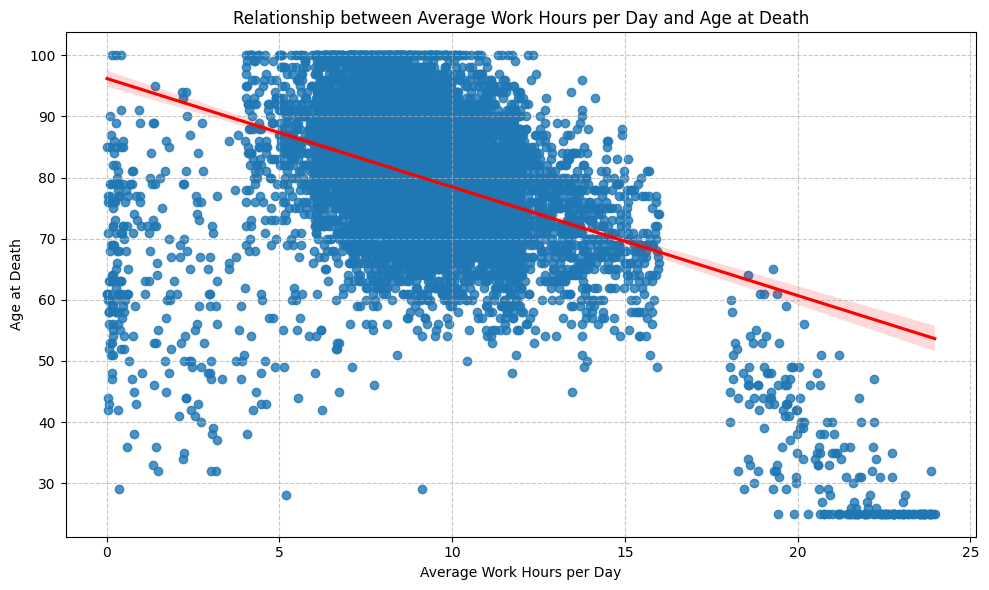

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='avg_work_hours_per_day', y='age_at_death', data=df, line_kws={'color': 'red'})
plt.title('Relationship between Average Work Hours per Day and Age at Death')
plt.xlabel('Average Work Hours per Day')
plt.ylabel('Age at Death')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Performing Machine Learning to Understand the Data

# Task
Analyze the "Quality of Life Data" from "/content/drive/MyDrive/Colab Notebooks/Data Science Project/Updated Quality of Life Data.csv" to identify factors influencing 'age_at_death' by preparing the data for machine learning, training a model to predict 'age_at_death', evaluating its performance, and analyzing feature importance to summarize key insights.

## Prepare Data for Machine Learning

### Subtask:
Prepare the dataset for machine learning by converting categorical variables into numerical format using one-hot encoding and splitting the data into features (X) and target (y). Then, split these into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
To prepare the data for machine learning, I will first separate the target variable 'age_at_death' from the features, drop the 'id' column, apply one-hot encoding to the categorical features, and then split the data into training and testing sets.



In [28]:
from sklearn.model_selection import train_test_split

# 1. Separate the target variable 'age_at_death' into y, and features into X
X = df.drop('age_at_death', axis=1)
y = df['age_at_death']

# 2. Drop the 'id' column from the X DataFrame
X = X.drop('id', axis=1)

# 3. Convert categorical columns ('gender' and 'occupation_type') into numerical format using one-hot encoding
X = pd.get_dummies(X, columns=['gender', 'occupation_type'], drop_first=True)

# 4. Split the preprocessed features (X) and target variable (y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("First 5 rows of preprocessed X:")
print(X.head())

Shape of X_train: (8000, 18)
Shape of X_test: (2000, 18)
Shape of y_train: (8000,)
Shape of y_test: (2000,)
First 5 rows of preprocessed X:
   avg_work_hours_per_day  avg_rest_hours_per_day  avg_sleep_hours_per_day  \
0                    6.60                   10.92                     5.38   
1                    9.65                    7.65                     6.31   
2                   13.77                    1.00                     8.02   
3                   10.94                    5.18                     7.59   
4                    9.81                    5.11                     7.38   

   avg_exercise_hours_per_day  gender_Male  occupation_type_Consultant  \
0                        1.10        False                       False   
1                        0.39         True                       False   
2                        1.21        False                       False   
3                        0.29        False                       False   
4                    

## Train a Machine Learning Model

### Subtask:
Train a machine learning model (e.g., RandomForestRegressor) on the training data. This model will learn the relationships between the features and the 'age_at_death' target variable.


**Reasoning**:
I will import the `RandomForestRegressor` model, instantiate it with a `random_state` for reproducibility, and then train it using the `X_train` and `y_train` datasets.



In [29]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test set using appropriate metrics such as R-squared and Mean Absolute Error, and visualize actual vs. predicted values.


**Reasoning**:
To evaluate the trained model's performance, I will first make predictions on the test set, then calculate R-squared and Mean Absolute Error, and finally visualize the actual versus predicted values using a scatter plot.



R-squared score: 0.53
Mean Absolute Error (MAE): 6.69


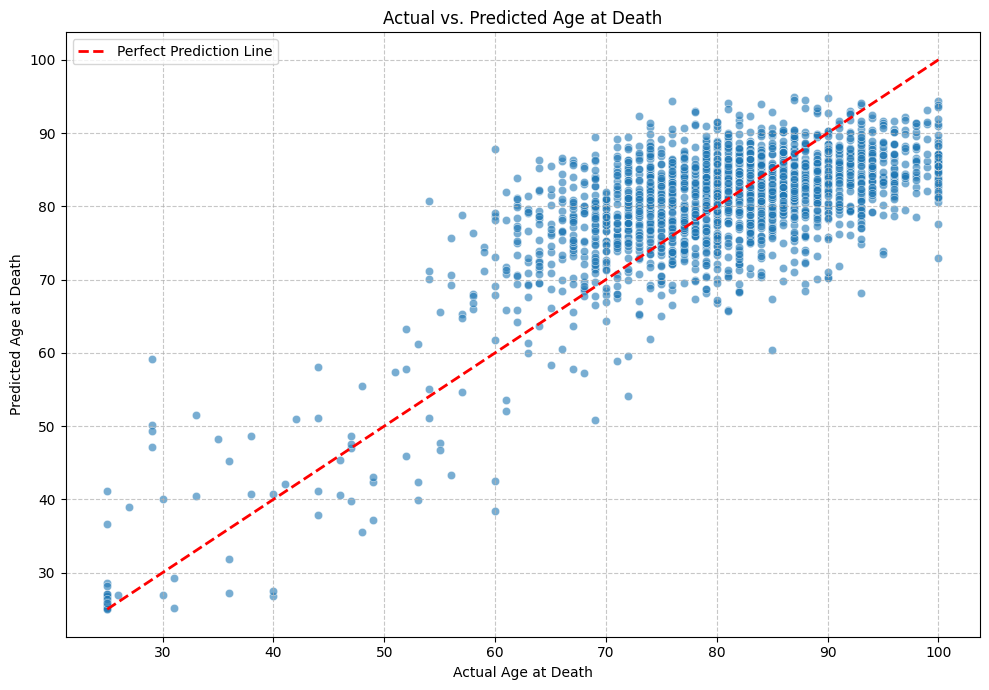

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trained model to make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 2. Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2:.2f}")

# 3. Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# 4. Create a scatter plot to visualize actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Add a diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Age at Death')
plt.xlabel('Actual Age at Death')
plt.ylabel('Predicted Age at Death')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Analyze Feature Importance

### Subtask:
Determine the importance of each feature in predicting 'age_at_death' using the trained model's feature importance attribute, and visualize these importances.


**Reasoning**:
To determine and visualize feature importance, I will extract `feature_importances_` from the `model`, create a DataFrame mapping these importances to feature names, sort the features by importance, and finally generate a horizontal bar plot to display the results effectively.

**Reasoning**:
To analyze feature importance, I will access the trained model's feature importances, pair them with the corresponding feature names, sort them in descending order, and then visualize them using a horizontal bar plot for clear interpretation.



/tmp/ipython-input-4037647427.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


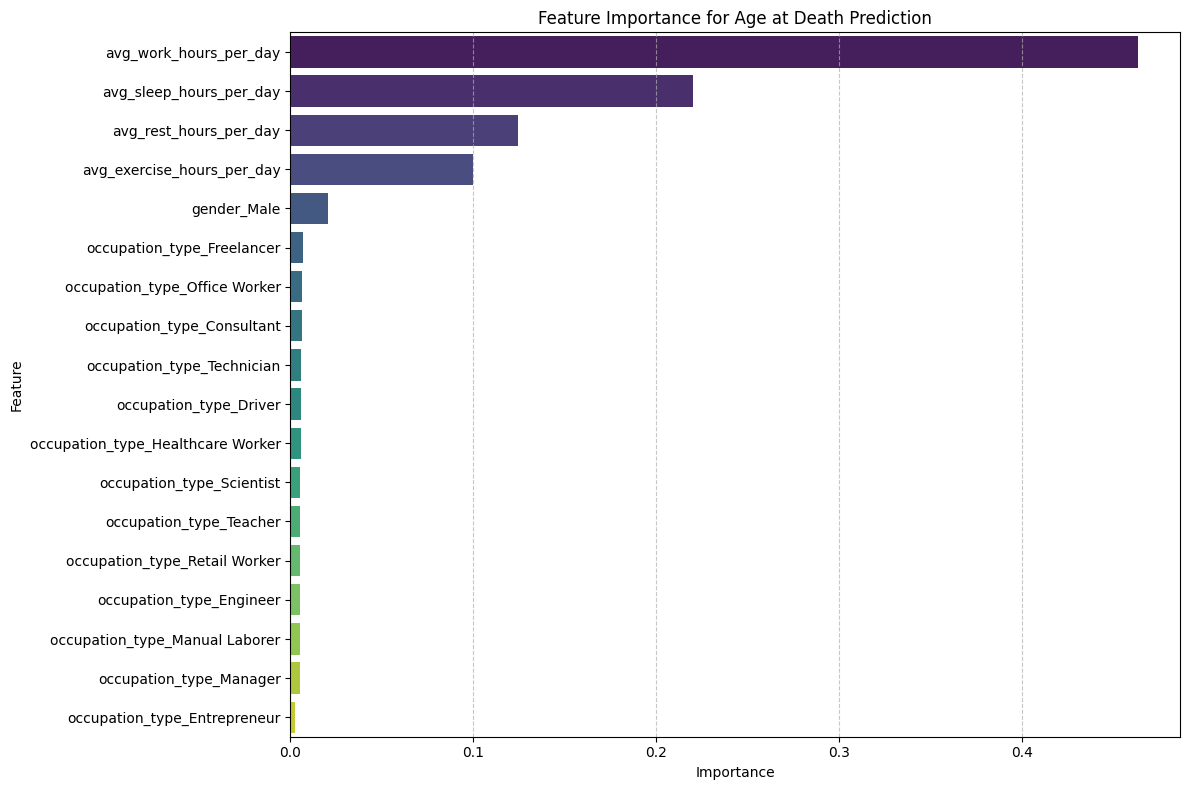

Top 10 most important features:
                           Feature  Importance
0          avg_work_hours_per_day    0.463191
2         avg_sleep_hours_per_day    0.220308
1          avg_rest_hours_per_day    0.124482
3      avg_exercise_hours_per_day    0.100087
4                     gender_Male    0.020814
9      occupation_type_Freelancer    0.007091
13  occupation_type_Office Worker    0.006278
5      occupation_type_Consultant    0.006158
17     occupation_type_Technician    0.005722
6          occupation_type_Driver    0.005604


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Access the feature_importances_ attribute of the trained model
feature_importances = model.feature_importances_

# 2. Create a Pandas Series to store these importances, mapping them to the original feature names
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 3. Sort the features by their importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Create a horizontal bar plot to visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Age at Death Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 most important features:\n", importance_df.head(10))

**Reasoning**:
The previous code produced a `FutureWarning` related to the `palette` argument in `seaborn.barplot`. To resolve this and ensure future compatibility, I will explicitly set the `hue` argument to the same variable as `y` ('Feature') and set `legend=False` as suggested by the warning.



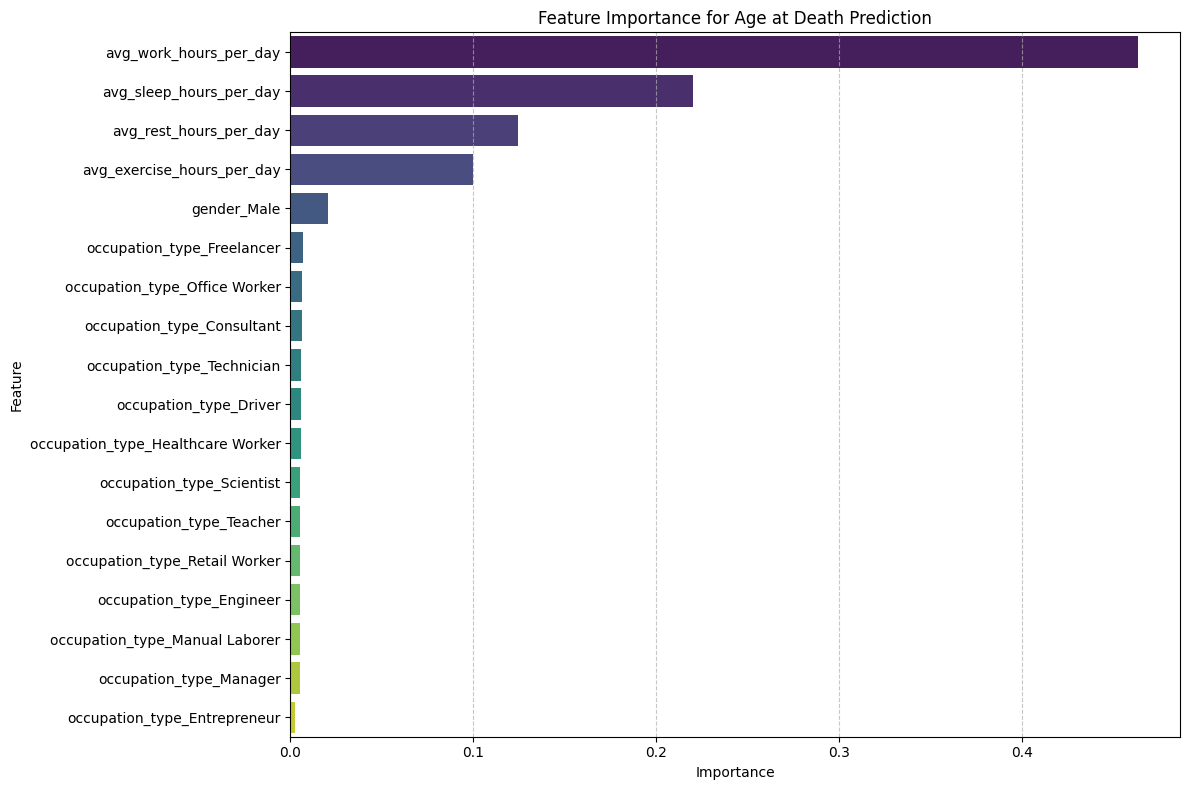

Top 10 most important features:
                           Feature  Importance
0          avg_work_hours_per_day    0.463191
2         avg_sleep_hours_per_day    0.220308
1          avg_rest_hours_per_day    0.124482
3      avg_exercise_hours_per_day    0.100087
4                     gender_Male    0.020814
9      occupation_type_Freelancer    0.007091
13  occupation_type_Office Worker    0.006278
5      occupation_type_Consultant    0.006158
17     occupation_type_Technician    0.005722
6          occupation_type_Driver    0.005604


In [32]:

# 1. Access the feature_importances_ attribute of the trained model
feature_importances = model.feature_importances_

# 2. Create a Pandas Series to store these importances, mapping them to the original feature names
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 3. Sort the features by their importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Create a horizontal bar plot to visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', legend=False)
plt.title('Feature Importance for Age at Death Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 most important features:\n", importance_df.head(10))

## Final Task

### Subtask:
Summarize the insights gained from the machine learning analysis, including key features influencing 'age_at_death' and the model's predictive capability.


## Summary:

### Q&A
*   **What are the key features influencing 'age\_at\_death'?**
    The most influential features predicting 'age\_at\_death' are `avg_work_hours_per_day` (0.463 importance), `avg_sleep_hours_per_day` (0.220 importance), `avg_rest_hours_per_day` (0.124 importance), and `avg_exercise_hours_per_day` (0.100 importance). These four features collectively account for over 90% of the model's predictive power.
*   **What is the model's predictive capability?**
    The RandomForestRegressor model achieved an R-squared score of 0.53, indicating it explains approximately 53% of the variance in 'age\_at\_death'. The Mean Absolute Error (MAE) was 6.69, meaning that on average, the model's predictions for age at death were off by about 6.69 years.

### Data Analysis Key Findings
*   The dataset was successfully prepared for machine learning by dropping the 'id' column, one-hot encoding categorical variables (`gender` and `occupation_type`), and splitting into training (8000 samples, 18 features) and testing (2000 samples, 18 features) sets.
*   A RandomForestRegressor model was trained to predict 'age\_at\_death'.
*   The model achieved an R-squared score of 0.53 on the test set, indicating a moderate ability to explain the variance in 'age\_at\_death'.
*   The Mean Absolute Error (MAE) was calculated as 6.69, suggesting predictions are, on average, within approximately 6.69 years of the actual age at death.
*   Feature importance analysis revealed that `avg_work_hours_per_day` is the most significant predictor with an importance of 0.463, followed by `avg_sleep_hours_per_day` (0.220), `avg_rest_hours_per_day` (0.124), and `avg_exercise_hours_per_day` (0.100).
*   Other features, such as `gender_Male` (0.021) and various `occupation_type` categories, had substantially lower importance scores, suggesting their impact on 'age\_at\_death' is less pronounced in this model.

### Insights or Next Steps
*   The overwhelming importance of daily activity patterns (work, sleep, rest, exercise hours) suggests that lifestyle factors are primary determinants of 'age\_at\_death' in this dataset. Future interventions or studies could focus on optimizing these factors for improved longevity.
*   While the model provides a good baseline (R-squared of 0.53), further model tuning, exploring other algorithms (e.g., gradient boosting), or incorporating additional relevant features (e.g., diet, medical history, stress levels) could improve the predictive accuracy and reduce the MAE.
